In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# 3.1 SARIMA as Baseline Time Series

In [14]:
# Load only required columns from the engineered full dataset
cols = ['Product', 'region', 'year_quarter', 'State', 'Date received']
df = pd.read_parquet("../data/processed/full_dataset.parquet", columns=cols)

In [15]:
print(f"Loaded {len(df):,} rows & {len(df.columns)} columns")
df.head()

Loaded 13,724,135 rows & 5 columns


,Product,region,year_quarter,State,Date received
0,Mortgage,South,2020Q3,AL,2020-07-13
1,Credit reporting or other personal consumer re...,Northeast,2023Q4,NY,2023-12-16
2,Credit reporting or other personal consumer re...,Northeast,2024Q1,NY,2024-01-27
3,"Credit reporting, credit repair services, or o...",West,2019Q2,CA,2019-05-22
4,Credit reporting or other personal consumer re...,South,2023Q4,FL,2023-12-21


### 3.1.1 Preparing SARIMA Time Series

In [16]:
# Filter to Credit reporting and build South vs Non-South quarterly series
if 'region' not in df.columns:
    # Fallback mapping if a non-engineered dataset is loaded accidentally
    northeast = ['CT','ME','MA','NH','RI','VT','NJ','NY','PA']
    midwest   = ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD']
    south     = ['DE','FL','GA','MD','NC','SC','VA','DC','WV','AL','KY','MS','TN','AR','LA','OK','TX']
    west      = ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA']
    def _map_region(state):
        if state in northeast:
            return 'Northeast'
        elif state in midwest:
            return 'Midwest'
        elif state in south:
            return 'South'
        elif state in west:
            return 'West'
        return np.nan
    df['region'] = df['State'].apply(_map_region)
    df = df.dropna(subset=['region'])

if 'year_quarter' not in df.columns:
    df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
    df['year_quarter'] = df['Date received'].dt.to_period('Q').astype(str)

df_cr = df[df['Product'].str.contains('Credit reporting', case=False, na=False)].copy()
df_cr['segment'] = np.where(df_cr['region'].eq('South'), 'South', 'Non-South')

quarterly_counts = (
    df_cr.groupby(['year_quarter', 'segment'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
quarterly_counts.index = pd.PeriodIndex(quarterly_counts.index, freq='Q')

print(f"Credit reporting rows: {len(df_cr):,}")
quarterly_counts.tail()

Credit reporting rows: 10,880,994


segment,Non-South,South
year_quarter,,
2025Q1,434232,572802
2025Q2,451637,643347
2025Q3,528182,784492
2025Q4,593557,917786
2026Q1,365206,549995


Shape: (54, 2)
segment       Non-South   South
year_quarter                   
2025Q1           434232  572802
2025Q2           451637  643347
2025Q3           528182  784492
2025Q4           593557  917786
2026Q1           365206  549995


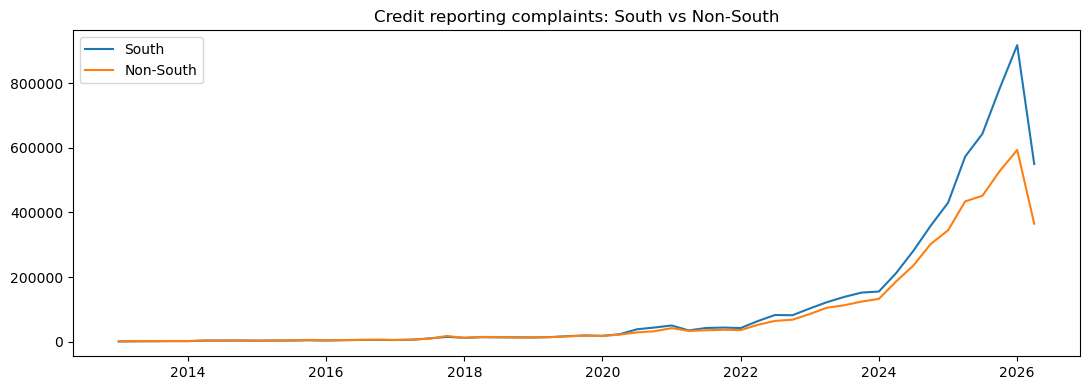

In [17]:
print("Shape:", quarterly_counts.shape)
print(quarterly_counts.tail())

fig, ax = plt.subplots(figsize=(11, 4))
for seg in ['South', 'Non-South']:
    s = quarterly_counts[seg].copy()
    s.index = s.index.to_timestamp(how='end')
    ax.plot(s.index, s.values, label=seg)
ax.set_title('Credit reporting complaints: South vs Non-South')
ax.legend()
plt.tight_layout()
plt.show()

### 3.1.2 Differencing Fix

In [18]:
# Stationarity test by segment
adf_rows = []
for seg in ['South', 'Non-South']:
    ts = quarterly_counts[seg].astype(float)
    adf_p = adfuller(ts)[1]
    adf_rows.append({'segment': seg, 'adf_p_raw': adf_p})

adf_df = pd.DataFrame(adf_rows)
adf_df

,segment,adf_p_raw
0,South,1.000000
1,Non-South,0.997219


In [19]:
# First-difference stationarity by segment
for seg in ['South', 'Non-South']:
    ts = quarterly_counts[seg].astype(float)
    ts_diff = ts.diff().dropna()
    pval = adfuller(ts_diff)[1]
    print(f"{seg} differenced ADF p-value: {pval:.4f}")

South differenced ADF p-value: 0.9130
Non-South differenced ADF p-value: 0.9103


### 3.1.3 Simpler SARIMA

In [20]:
# Fit SARIMA by segment
sarima_results = {}

for seg in ['South', 'Non-South']:
    ts = quarterly_counts[seg].astype(float)
    test_size = 8 if len(ts) >= 24 else max(4, int(round(len(ts) * 0.2)))
    test_size = min(test_size, len(ts) - 8) if len(ts) > 12 else max(1, len(ts)//3)
    train = ts.iloc[:-test_size]
    test = ts.iloc[-test_size:]

    model = SARIMAX(
        train,
        order=(1, 1, 0),
        seasonal_order=(1, 1, 0, 4),
        trend='c'
    )
    fitted = model.fit(disp=False)
    pred = fitted.forecast(steps=len(test))
    pred.index = test.index

    final_model = SARIMAX(ts, order=(1, 1, 0), seasonal_order=(1, 1, 0, 4), trend='c')
    final_fit = final_model.fit(disp=False)
    fc = final_fit.forecast(steps=4)
    fc_index = pd.period_range(start=ts.index[-1] + 1, periods=4, freq='Q')
    fc = pd.Series(fc.values, index=fc_index)

    sarima_results[seg] = {'ts': ts, 'test': test, 'pred': pred, 'forecast': fc, 'fit': final_fit}

print('SARIMA fitted for segments:', list(sarima_results.keys()))

SARIMA fitted for segments: ['South', 'Non-South']


### 3.1.4 Forecast & Plot

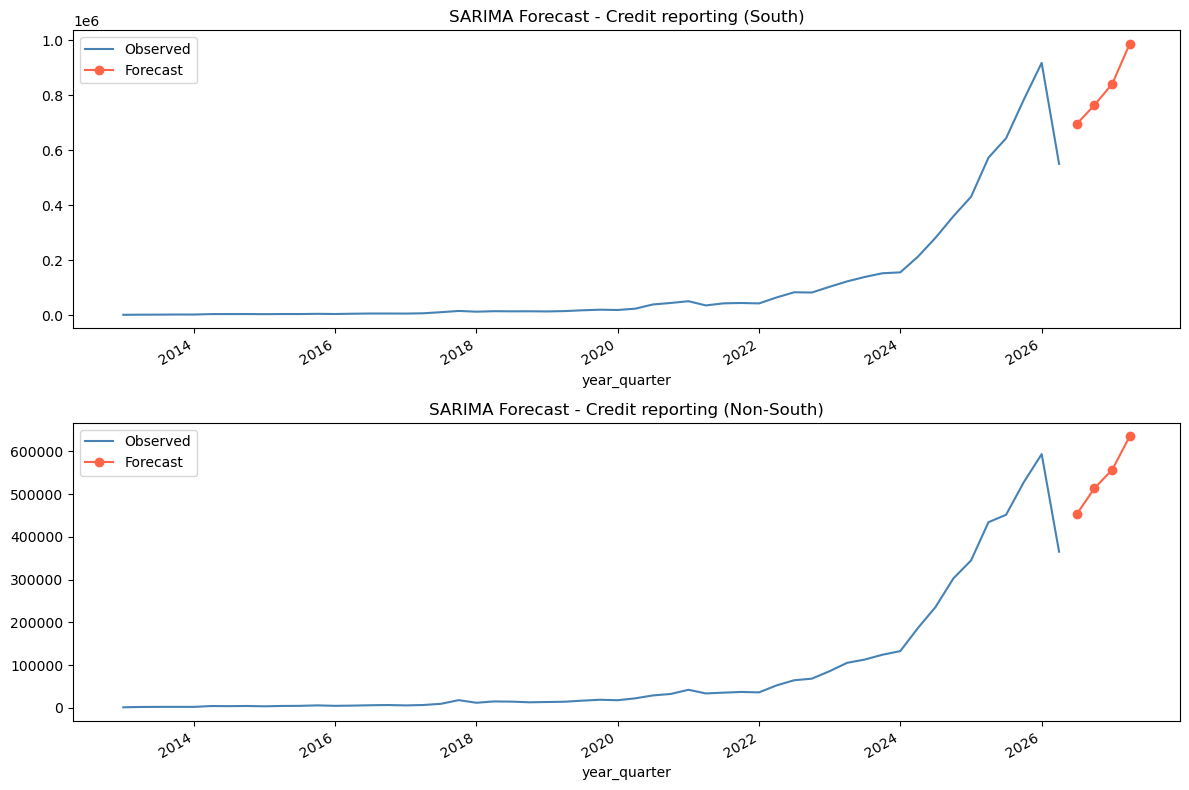


Next 4Q Forecast:

South:
2026Q2    695011.0
2026Q3    764249.0
2026Q4    841364.0
2027Q1    986916.0
Freq: Q-DEC, dtype: float64

Non-South:
2026Q2    452935.0
2026Q3    513751.0
2026Q4    557251.0
2027Q1    635078.0
Freq: Q-DEC, dtype: float64


In [21]:
# Forecast plot by segment
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for i, seg in enumerate(['South', 'Non-South']):
    ax = axes[i]
    out = sarima_results[seg]
    ts = out['ts']
    fc = out['forecast']

    ts_plot = pd.Series(ts.values, index=ts.index.to_timestamp(how='end'))
    fc_plot = pd.Series(fc.values, index=fc.index.to_timestamp(how='end'))

    ts_plot.plot(ax=ax, label='Observed', color='steelblue')
    fc_plot.plot(ax=ax, label='Forecast', color='tomato', marker='o')
    ax.set_title(f'SARIMA Forecast - Credit reporting ({seg})')
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/sarima_credit_reporting_south_vs_others.png', dpi=150)
plt.show()

print('\nNext 4Q Forecast:')
for seg in ['South', 'Non-South']:
    print(f'\n{seg}:')
    print(sarima_results[seg]['forecast'].round(0))

### 3.1.5 MAE

In [22]:
# Holdout MAE by segment
rows = []
for seg in ['South', 'Non-South']:
    test = sarima_results[seg]['test']
    pred = sarima_results[seg]['pred']
    mae = np.mean(np.abs(test - pred))
    pct_err = mae / sarima_results[seg]['ts'].mean() * 100
    rows.append({'segment': seg, 'holdout_mae': round(mae, 1), 'mae_pct_of_mean': round(pct_err, 1)})

sarima_summary = pd.DataFrame(rows)
sarima_summary

,segment,holdout_mae,mae_pct_of_mean
0,South,262033.6,228.5
1,Non-South,130565.8,150.4


### 3.1.6 Results (Segmented SARIMA)

Segment-level SARIMA baseline was fit using SARIMA(1,1,0)(1,1,0,4) with a constant trend for both **South** and **Non-South** Credit Reporting series.

| Metric | South | Non-South | Interpretation |
| --- | ---: | ---: | --- |
| ADF p-value (raw series) | 1.0000 | 0.9972 | Both series are non-stationary in levels |
| ADF p-value (1st diff) | 0.9130 | 0.9103 | Differencing alone still leaves strong persistence / trend effects |
| AIC | 1241.730 | 1198.347 | In-sample fit is comparable across segments |
| Holdout MAE | 262,033.6 | 130,565.8 | South has materially larger absolute forecast error |
| MAE as % of segment mean | 228.5% | 150.4% | Baseline error remains high for both segments |

**4-quarter forecast (from latest available quarter):**
- South: 695,011 -> 764,249 -> 841,364 -> 986,916
- Non-South: 452,935 -> 513,751 -> 557,251 -> 635,078

**Visual and modeling insights**
- Both segment series show sharp growth in recent quarters, especially South.
- Forecast trajectories are strongly upward for both segments, with larger absolute levels in South.
- High holdout MAE and very high MAE% indicate this SARIMA specification is a weak baseline under current volatility/regime shifts.

**Limitations and next-step direction**
- Residual non-stationarity suggests richer structure is needed (additional differencing checks, drift alternatives, or exogenous regressors).
- Segment-wise model tuning should be considered separately instead of enforcing one fixed order for both series.
- Compare against stronger baselines (e.g., XGBoost / NeuralProphet in Sections 3.2 and 3.3) before selecting a final model.